# SASA

**Paper**: [Large Language Models Can Become Strong Self-Detoxifiers](https://openreview.net/pdf?id=jY5oml9fe9)

**Authors**: Ching-Yun Ko, Pin-Yu Chen, Payel Das, Youssef Mroueh, Soham Dan, Georgios Kollias, Subhajit Chaudhury, Tejaswini Pedapati, Luca Daniel

SASA (self-disciplined autoregressive sampling) fits a closed-form linear classifier (a Fisher discriminant) in the model's own final-layer space from labeled prompt and response pairs. At each decoding step it reads the candidate tokens' margins to that classifier with a same-model forward, and shifts the candidate logits by `beta * softmax(margin)`, which is the optimum of the expected-margin objective under a KL penalty to the original distribution (Proposition 1 in the paper).

In this notebook we use SASA to self-steer a modern instruct model toward a style attribute, plain-language readability, with no external model anywhere in the loop. The attribute data are the model's own responses, elicited under two style instructions and labeled by the Flesch-Kincaid grade formula. The probe is fit on chat-rendered prompt and response pairs that do not contain the style instruction, and at decode time SASA steers responses to prompts that carry no style instruction at all. We read the results against the style-prompted model, since prompting is what a practitioner would reach for first, and SASA adds a continuous strength dial over it, consumes no context, composes with other controls, and applies when the prompt cannot be changed.

## Method parameters

| parameter | type | description |
| --- | --- | --- |
| `beta` | `float` | Scaling coefficient for the margin shift. Must be non-negative; `0` reproduces the base decoding. |
| `wv_path` | `str \| None` | Path to a saved probe: a probe directory, a `.probe` JSON file, or a `.pt` legacy tensor checkpoint. |
| `gen_wv_data` | `dict \| LabeledExamples \| ContrastivePairs \| None` | In-memory labeled data used to fit the probe. A `{'pos', 'neg'}` dict or `LabeledExamples` gives unpaired classes; a dict with a `'prompts'` key or a `ContrastivePairs` gives paired prompt and response data. |
| `prompt_format` | `str` | How fit data is rendered before capture: `raw`, `chat_completion`, or `chat_prompt`. `chat_completion` requires the paired form. |
| `candidate_policy` | `str` | Which tokens are scored per step: `surviving`, `top_p` (the nucleus of the raw logits, the paper's setting), or `top_k`. |
| `top_p` / `top_k` | `float` / `int` | Candidate sizing for `candidate_policy='top_p'` / `'top_k'`. |
| `max_candidates` | `int \| None` | Clamp on the candidate set (top-N by score) to bound the per-step forward. |
| `gen_wv_length` | `int \| None` | Maximum samples per class used to fit the probe when `wv_path` is unset. |
| `gen_wv_batch_size` | `int \| None` | Batch size for the probe fit when `wv_path` is unset. |

The `value_trace` runtime kwarg receives one record per scored decoding step (the candidate ids, their pre-shift scores, the raw margins, and the normalized shift), used in the mechanism section below.

## Setup

If running this from a Google Colab notebook, uncomment the following cell to install the toolkit. This is not necessary in a virtual environment where the package is already installed.

In [1]:
# !git clone https://github.com/IBM/steerability.git
# %cd steerability

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textstat
import torch
from datasets import load_dataset

from steerability.algorithms.core.internals.data import ContrastivePairs
from steerability.algorithms.core.internals.probes import evaluate_probe
from steerability.algorithms.core.steering_pipeline import SteeringPipeline
from steerability.algorithms.output_control.sasa.control import SASA
from steerability.evaluation.plotting import apply_plot_style, plot_metric_by_config, plot_tradeoff_scatter
from steerability.utils.verbosity import quiet_third_party

quiet_third_party()  # optional: reduce third-party progress bars and info logs
apply_plot_style()

In [3]:
from pathlib import Path

MODEL_ID = "ibm-granite/granite-4.1-3b"
NOTEBOOK_DIR = Path("artifacts/sasa")
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

NUM_FIT_PROMPTS = 240
NUM_EVAL_PROMPTS = 30
SIMPLE_GRADE_MAX = 7.0
COMPLEX_GRADE_MIN = 12.0
BETAS = [10, 30, 60]  # fixed from the margin scale (about one logit unit; see the mechanism section)
CANDIDATE_TOP_K = 20
TOP_P = 0.9
MAX_CANDIDATES = 32
MAX_NEW_TOKENS = 128
SEED = 0

PLAIN_INSTRUCTION = (
    "Answer for a general audience at a sixth-grade reading level, using short sentences and everyday words."
)
DENSE_INSTRUCTION = (
    "Answer as a specialist writing for specialists, using precise technical vocabulary and complex sentences."
)

## Prompts

We draw open-ended question prompts from the Dolly instruction dataset, keeping the `open_qa` and `general_qa` rows with no supporting context so that each prompt is answerable on its own. We shuffle with a fixed seed and split into a fit set and a disjoint evaluation set.

In [4]:
dolly = load_dataset("databricks/databricks-dolly-15k", split="train")
open_qa = [
    row["instruction"].strip()
    for row in dolly
    if row["category"] in {"open_qa", "general_qa"} and not row["context"].strip()
]

rng = np.random.default_rng(SEED)
rng.shuffle(open_qa)
fit_prompts = open_qa[:NUM_FIT_PROMPTS]
eval_prompts = open_qa[NUM_FIT_PROMPTS:NUM_FIT_PROMPTS + NUM_EVAL_PROMPTS]

pd.DataFrame({"prompt": fit_prompts[:5]})

,prompt
0,Name 5 different vegetables. List them with da...
1,Is Spain a good place to live?
2,Why is pickleball so popular in the US right now?
3,"In a bingo game, which number is represented b..."
4,Is a Handball a 'Direct' or 'Indirect' Kick?


## Eliciting attribute data

We build the attribute data from the model's own responses. An unsteered pipeline (`controls=[]`) answers every fit prompt twice, once under `PLAIN_INSTRUCTION` and once under `DENSE_INSTRUCTION` as the system message. The unsteered pipeline supports batching, so both passes run batched.

In [5]:
elicit_pipeline = SteeringPipeline(
    model_name_or_path=MODEL_ID,
    controls=[],
    device_map="auto",
)
elicit_pipeline.steer()

elicit_params = dict(
    max_new_tokens=MAX_NEW_TOKENS, do_sample=True, temperature=1.0, top_p=TOP_P,
    seed=SEED, seed_scope="dispatch",
)
plain_conversations = [
    [{"role": "system", "content": PLAIN_INSTRUCTION}, {"role": "user", "content": prompt}]
    for prompt in fit_prompts
]
dense_conversations = [
    [{"role": "system", "content": DENSE_INSTRUCTION}, {"role": "user", "content": prompt}]
    for prompt in fit_prompts
]
plain_responses = elicit_pipeline.generate(messages=plain_conversations, **elicit_params)
dense_responses = elicit_pipeline.generate(messages=dense_conversations, **elicit_params)

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Each response is labeled by its Flesch-Kincaid grade, a formula over word and sentence length that needs no model. A prompt is kept when its plain response scores at or below `SIMPLE_GRADE_MAX` and its dense response at or above `COMPLEX_GRADE_MIN`, so the two classes are separated by the label rule rather than by the instruction. The kept pairs form a `ContrastivePairs` whose prompts are the user turns, with the last twenty percent held out for evaluation. Note that the instruction never enters the rendered fit text, only the plain user prompt and the response do.

In [6]:
plain_grades = [textstat.flesch_kincaid_grade(r) for r in plain_responses]
dense_grades = [textstat.flesch_kincaid_grade(r) for r in dense_responses]

kept = [
    i for i in range(len(fit_prompts))
    if plain_grades[i] <= SIMPLE_GRADE_MAX and dense_grades[i] >= COMPLEX_GRADE_MIN
]
prompts = [fit_prompts[i] for i in kept]
plain = [plain_responses[i] for i in kept]
dense = [dense_responses[i] for i in kept]

split = int(len(kept) * 0.8)
fit_pairs = ContrastivePairs(positives=plain[:split], negatives=dense[:split], prompts=prompts[:split])
held_out_pairs = ContrastivePairs(positives=plain[split:], negatives=dense[split:], prompts=prompts[split:])

print(f"kept {len(kept)} of {len(fit_prompts)} prompts; {len(fit_pairs.positives)} for fitting, "
      f"{len(held_out_pairs.positives)} held out")

kept 128 of 240 prompts; 102 for fitting, 26 held out


The two grade distributions show the separation the label rule enforces.

findfont: Failed to find font weight medium, now using 400.


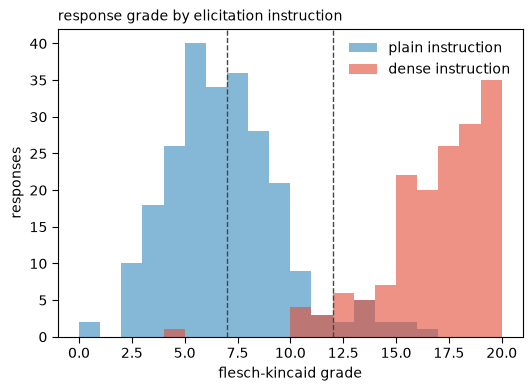

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(0, 20, 21)
ax.hist(plain_grades, bins=bins, alpha=0.6, label="plain instruction")
ax.hist(dense_grades, bins=bins, alpha=0.6, label="dense instruction")
ax.axvline(SIMPLE_GRADE_MAX, color="#444444", linestyle="--", linewidth=1)
ax.axvline(COMPLEX_GRADE_MIN, color="#444444", linestyle="--", linewidth=1)
ax.set_xlabel("flesch-kincaid grade")
ax.set_ylabel("responses")
ax.set_title("response grade by elicitation instruction", loc="left", fontweight="medium", fontsize=10)
ax.legend(frameon=False)
plt.show()

## Fitting the subspace

We fit SASA on the paired data, reusing the model already loaded for elicitation so that a single 3B model stays resident throughout. With `prompt_format="chat_completion"`, `steer()` renders each pair through the chat template as a user turn plus the response, captures the final-layer state at the response's last token, fits the Fisher direction that separates the plain and dense classes, and calibrates the bias at the class midpoint.

The paper scores the nucleus of the raw logits at each step. Note that a confident instruct model often assigns almost all of its probability to a single next token, so at `top_p=0.9` the nucleus is one or two candidates and the softmax over their margins has nothing to redistribute. We therefore score a fixed set of the top `CANDIDATE_TOP_K` candidates, which gives the margin enough candidates to shift mass between while staying close to the base distribution. The set is clamped to `MAX_CANDIDATES` on top of the policy.

In [8]:
model = elicit_pipeline.model
tokenizer = elicit_pipeline.tokenizer

sasa = SASA(
    beta=BETAS[1],
    gen_wv_data=fit_pairs,
    prompt_format="chat_completion",
    candidate_policy="top_k",
    top_k=CANDIDATE_TOP_K,
    max_candidates=MAX_CANDIDATES,
    gen_wv_batch_size=8,
)

pipeline = SteeringPipeline(model=model, tokenizer=tokenizer, controls=[sasa])
pipeline.steer()

probe_dir = NOTEBOOK_DIR / "probe"
sasa.probe.save(probe_dir)

## Held-out separation

The paper's central claim is that the model's own embedding space already carries the attribute. We check it by scoring the held-out pairs against the fitted probe with `evaluate_probe`, which renders and pools in the probe's recorded space and applies its decision function without refitting.

In [9]:
evaluation = evaluate_probe(
    sasa.probe,
    pipeline.model,
    pipeline.tokenizer,
    held_out_pairs,
    prompt_format="chat_completion",
)
print(f"held-out accuracy {evaluation.accuracy:.2f}, f1 {evaluation.f1:.2f}")

held-out accuracy 0.98, f1 0.98


The margin histograms show how the two held-out classes separate along the fitted direction.

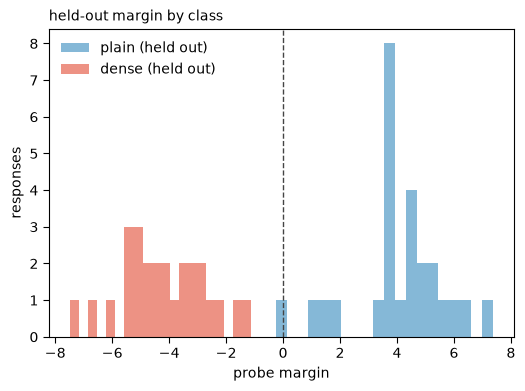

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(evaluation.positive_scores.numpy(), bins=20, alpha=0.6, label="plain (held out)")
ax.hist(evaluation.negative_scores.numpy(), bins=20, alpha=0.6, label="dense (held out)")
ax.axvline(0.0, color="#444444", linestyle="--", linewidth=1)
ax.set_xlabel("probe margin")
ax.set_ylabel("responses")
ax.set_title("held-out margin by class", loc="left", fontweight="medium", fontsize=10)
ax.legend(frameon=False)
plt.show()

## Steering

For each evaluation prompt we generate three ways: the unsteered pipeline with no system message, the unsteered pipeline under `PLAIN_INSTRUCTION` (the prompted reference), and SASA at each `beta`. SASA reuses the loaded model and tokenizer, so each `beta` is a fresh pipeline over the same weights. SASA tracks a batch-size-one margin, so the steered prompts run one at a time; generation is seeded and uses the same sampling parameters throughout.

In [11]:
gen_params = dict(do_sample=True, temperature=1.0, top_p=TOP_P, max_new_tokens=MAX_NEW_TOKENS, seed=SEED)

sasa_pipelines = {}
for beta in BETAS:
    control = SASA(
        beta=beta,
        wv_path=str(probe_dir),
        candidate_policy="top_k",
        top_k=CANDIDATE_TOP_K,
        max_candidates=MAX_CANDIDATES,
    )
    beta_pipeline = SteeringPipeline(model=model, tokenizer=tokenizer, controls=[control])
    beta_pipeline.steer()
    sasa_pipelines[beta] = beta_pipeline

rows = []
for prompt_id, prompt in enumerate(eval_prompts):
    user_turn = [{"role": "user", "content": prompt}]
    prompted_turn = [{"role": "system", "content": PLAIN_INSTRUCTION}] + user_turn
    rows.append({"configuration": "baseline", "beta": 0, "prompt_id": prompt_id,
                 "response": elicit_pipeline.generate(messages=user_turn, **gen_params)})
    rows.append({"configuration": "prompted", "beta": 0, "prompt_id": prompt_id,
                 "response": elicit_pipeline.generate(messages=prompted_turn, **gen_params)})
    for beta in BETAS:
        rows.append({"configuration": f"sasa_beta_{beta}", "beta": beta, "prompt_id": prompt_id,
                     "response": sasa_pipelines[beta].generate(messages=user_turn, **gen_params)})

responses = pd.DataFrame(rows)

## Metrics

We score each response by its Flesch-Kincaid grade, its mean words per sentence, and its perplexity under the unsteered pipeline. Perplexity is computed with `compute_logprobs` on the unsteered pipeline, so it measures fluency under the base model rather than under SASA. The prompt ids come from the chat-rendered user turn and the reference ids from the response tokens, scored one prompt at a time to avoid padding.

In [12]:
responses["fk_grade"] = [textstat.flesch_kincaid_grade(r) for r in responses["response"]]
responses["words_per_sentence"] = [
    textstat.lexicon_count(r) / max(textstat.sentence_count(r), 1) for r in responses["response"]
]

perplexities = []
for row in responses.itertuples():
    prompt_text = tokenizer.apply_chat_template(
        [{"role": "user", "content": eval_prompts[row.prompt_id]}],
        add_generation_prompt=True, tokenize=False,
    )
    prompt_ids = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
    ref_ids = tokenizer(row.response, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
    if ref_ids.size(1) == 0:
        perplexities.append(float("nan"))
        continue
    logprobs = elicit_pipeline.compute_logprobs(input_ids=prompt_ids, ref_output_ids=ref_ids)
    perplexities.append(float(torch.exp(-logprobs.mean())))
responses["perplexity"] = perplexities

summary = (
    responses.groupby("configuration")[["fk_grade", "words_per_sentence", "perplexity"]]
    .agg(["mean", "std"])
)
summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
config_order = ["baseline", "prompted"] + [f"sasa_beta_{b}" for b in BETAS]
summary = summary.reindex(config_order).reset_index()
summary

,configuration,fk_grade_mean,fk_grade_std,words_per_sentence_mean,words_per_sentence_std,perplexity_mean,perplexity_std
0,baseline,12.026245,2.281162,18.703095,3.924353,1.245313,0.085054
1,prompted,6.879268,1.876552,13.418135,3.510563,10.637760,9.886316
2,sasa_beta_10,11.094362,2.147879,16.344921,3.687963,1.379427,0.171270
3,sasa_beta_30,9.738136,2.270963,13.840357,3.173851,3.311458,1.578301
4,sasa_beta_60,6.933320,4.484248,11.980873,5.545050,24.854167,52.317851


## Readability by configuration

We read the grade against the prompted reference. Increasing `beta` lowers the grade of responses to prompts that carry no style instruction, moving them toward the plain-language target without changing the prompt.

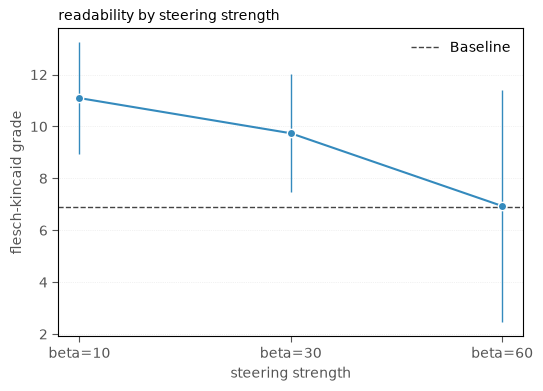

In [13]:
prompted_fk_grade = float(summary.loc[summary["configuration"] == "prompted", "fk_grade_mean"].iloc[0])
sasa_summary = summary[summary["configuration"].str.startswith("sasa_beta_")].copy()
sasa_summary["configuration"] = [f"beta={b}" for b in BETAS]

ax = plot_metric_by_config(
    sasa_summary,
    metric="fk_grade",
    x_col="configuration",
    baseline_value=prompted_fk_grade,
    title="readability by steering strength",
    xlabel="steering strength",
    ylabel="flesch-kincaid grade",
)
plt.show()

## Trade-off

Steering trades readability against fluency. Rising `beta` lowers the grade and raises perplexity, the same shape as the paper's Figure 3. The prompted reference sits at a different point because it changes the context rather than the sampling distribution.

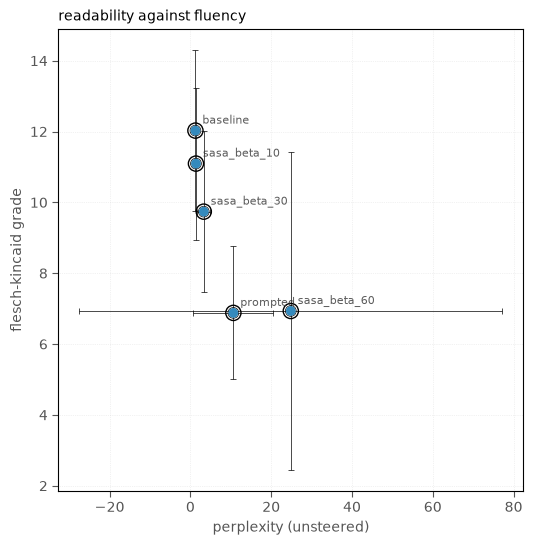

In [14]:
ax = plot_tradeoff_scatter(
    summary,
    x_metric="perplexity",
    y_metric="fk_grade",
    label_col="configuration",
    maximize_x=False,
    maximize_y=False,
    title="readability against fluency",
    xlabel="perplexity (unsteered)",
    ylabel="flesch-kincaid grade",
)
plt.show()

## Qualitative

We show three evaluation prompts under the baseline, SASA at the middle `beta`, and the prompted reference, then print two responses in full.

In [15]:
middle = BETAS[1]
qualitative = responses[responses["configuration"].isin(["baseline", f"sasa_beta_{middle}", "prompted"])]
qualitative = qualitative[qualitative["prompt_id"].isin([0, 1, 2])]
frame = qualitative.pivot(index="prompt_id", columns="configuration", values="response")
frame

configuration,baseline,prompted,sasa_beta_30
prompt_id,,,
0,"In China, there isn’t an exact direct equivale...","In China, the equivalent group of very success...",There isn’t a one‑to‑one “FAANG” equivalent in...
1,The reliability of public transportation can v...,"Public transportation can be pretty reliable, ...",The reliability of public transportation can v...
2,Viscosity is a measure of a fluid’s resistance...,Viscosity is a word that describes how thick o...,Viscosity is a measure of a fluid’s resistance...


In [16]:
example = responses[(responses["prompt_id"] == 0)]
print("prompt:", eval_prompts[0])
print()
print("baseline:")
print(example[example["configuration"] == "baseline"]["response"].iloc[0])
print()
print(f"sasa beta={middle}:")
print(example[example["configuration"] == f"sasa_beta_{middle}"]["response"].iloc[0])

prompt: What is the FAANG equivalent in China?

baseline:
In China, there isn’t an exact direct equivalent to the FAANG (Facebook, Amazon, Apple, Netflix, Google) acronym, as those companies are primarily U.S.-based. However, China has several tech giants that play a similar role in the global tech landscape, often referred to collectively as the "BAT" (百度, 腾讯, 阿里巴巴) or sometimes expanded to "BATD" (加入淘宝, which refers to Tmall, owned by Alibaba):

1. **Baidu (百度)** - China's answer to Google, primarily

sasa beta=30:
There isn’t a one‑to‑one “FAANG” equivalent in China, but there are several high‑profile technology companies headquartered in China (or with very significant operations there) that compete head‑to‑head with the Big F (Facebook, Amazon, Apple, Netflix, Google/Alphabet). These companies are often colloquially referred to as part of a “Double Eleven” or “Chinese FA”. Here are some of the most recognisable:

1. **阿里巴巴 (Alibaba) Group** – Primarily known for its e‑commerce pla

## Mechanism

We inspect one step of the redistribution with a `value_trace`. We generate one evaluation prompt at the middle `beta` while collecting a record per step, then pick the step with the largest margin spread and tabulate its candidates: the original probability (softmax of the pre-shift scores), the margin, and the adjusted probability (softmax of the scores plus `beta * normalized`). This is the paper's Figure 4 on the modern model.

We also report the margin scale, the median across steps of the per-step standard deviation of the margins, so `beta` reads against the logit gaps. The scale is about one logit unit, so a `beta` in the tens produces a shift comparable to the gaps between candidate logits. Within a step the shift demotes the candidates with the most negative margins, the tokens the probe reads as moving the text toward the dense class.

In [17]:
trace = []
mechanism_prompt = eval_prompts[0]
sasa_pipelines[middle].generate(
    messages=[{"role": "user", "content": mechanism_prompt}],
    runtime_kwargs={"value_trace": trace},
    **gen_params,
)

spreads = [float(record.values.std()) for record in trace]
margin_scale = float(np.median(spreads))
step = int(np.argmax(spreads))
record = trace[step]

original = torch.softmax(record.candidate_scores[0], dim=-1)
adjusted = torch.softmax(record.candidate_scores[0] + middle * record.normalized[0], dim=-1)
order = torch.argsort(adjusted, descending=True)[:8]

mechanism = pd.DataFrame({
    "token": [tokenizer.decode([record.candidate_ids[0, i]]) for i in order],
    "original_prob": original[order].tolist(),
    "margin": record.values[0, order].tolist(),
    "adjusted_prob": adjusted[order].tolist(),
})
print(f"margin scale (median per-step std of margins): {margin_scale:.3f}")
mechanism

margin scale (median per-step std of margins): 1.122


,token,original_prob,margin,adjusted_prob
0,‑,9.230018e-01,0.052734,9.967203e-01
1,-to,7.576460e-02,-1.234375,2.408277e-03
2,‐,1.080724e-03,-0.009827,8.686010e-04
3,-word,1.290741e-04,-4.156250,1.149804e-06
4,-,6.426220e-06,-0.640625,6.075646e-07
5,­,3.439708e-06,-0.582031,3.766681e-07
6,–,5.274962e-07,-0.119141,2.639945e-07
7,\-,2.823484e-07,-0.017578,2.190537e-07


## Cost

SASA runs up to `MAX_CANDIDATES` same-model single-token forwards per decoding step, sharing the prefix KV cache through `CandidateForward`. We report tokens per second for the unsteered pipeline and for SASA at the middle `beta` over ten prompts, along with the mean candidate count per step from the trace.

In [18]:
import time

cost_prompts = eval_prompts[:10]

start = time.perf_counter()
baseline_tokens = 0
for prompt in cost_prompts:
    response = elicit_pipeline.generate(messages=[{"role": "user", "content": prompt}], **gen_params)
    baseline_tokens += len(tokenizer(response, add_special_tokens=False).input_ids)
baseline_tps = baseline_tokens / (time.perf_counter() - start)

start = time.perf_counter()
sasa_tokens = 0
for prompt in cost_prompts:
    response = sasa_pipelines[middle].generate(messages=[{"role": "user", "content": prompt}], **gen_params)
    sasa_tokens += len(tokenizer(response, add_special_tokens=False).input_ids)
sasa_tps = sasa_tokens / (time.perf_counter() - start)

mean_candidates = float(np.mean([record.candidate_ids.size(1) for record in trace]))

pd.DataFrame({
    "configuration": ["baseline", f"sasa beta={middle}"],
    "tokens_per_second": [baseline_tps, sasa_tps],
    "mean_candidates_per_step": [np.nan, mean_candidates],
})

,configuration,tokens_per_second,mean_candidates_per_step
0,baseline,45.411844,NaN
1,sasa beta=30,14.893867,20.0


## Reusing the probe

The fitted probe is a saved artifact, so a new `SASA(beta=..., wv_path=...)` steers without refitting. Freezing the control with `to_spipe()` records the same form, carrying the candidate policy and clamp alongside the probe path.

In [19]:
reused = SASA(beta=middle, wv_path=str(probe_dir), candidate_policy="top_k", top_k=CANDIDATE_TOP_K,
              max_candidates=MAX_CANDIDATES)
reused_pipeline = SteeringPipeline(model=model, tokenizer=tokenizer, controls=[reused])
reused_pipeline.steer()  # loads the probe, no refit

print(reused_pipeline.generate(messages=[{"role": "user", "content": eval_prompts[1]}], **gen_params))

The reliability of public transportation can vary widely depending on several factors, including the location, the specific mode of transportation (bus, subway, train, etc.), the time of day, weather conditions, and the maintenance track record of the transit system. Generally, here are some points to consider:

1. **Location**: Reliability tends to be higher in cities with well-established and modern public transit systems. North America’s New York City Subway, Los Angeles Metro, and Los Angeles Metro Gold Line, for example, are known for their punctuality (on-time performance). Conversely, some mid-sized or rural transit systems may have lower reliability.

2


## Takeaways

The attribute is defined entirely by the labeling rule. Replacing the Flesch-Kincaid formula with a formality ranker, a sentiment classifier, or human labels swaps the attribute with no other change to the method, which is the paper's central claim. The probe is closed form and refits in seconds, and step-level controls compose, so a second attribute is a second `SASA` in the same pipeline.